In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.compat.v1 as tf1
tf.compat.v1.disable_v2_behavior() # 1.x 兼容模式
# TF 2.16+ disable_v2_behavior 不再导出 Session 等到顶层, 手动补上
tf.Session = tf1.Session
tf.placeholder = tf1.placeholder
tf.global_variables_initializer = tf1.global_variables_initializer
tf.Variable = tf1.Variable
tf.train = tf1.train
tf.layers = tf1.layers
tf.losses = tf1.losses


Instructions for updating:
non-resource variables are not supported in the long term


## 构造数据

In [3]:
np.random.seed(999)

In [4]:
raw_data = np.random.standard_normal((1000,2))
raw_data[:5]


array([[ 0.12715784,  1.40189088],
       [ 0.31481499, -0.85844916],
       [-0.26613444, -0.64890071],
       [ 1.56626757, -2.09137019],
       [ 1.45632806,  0.94529342]])

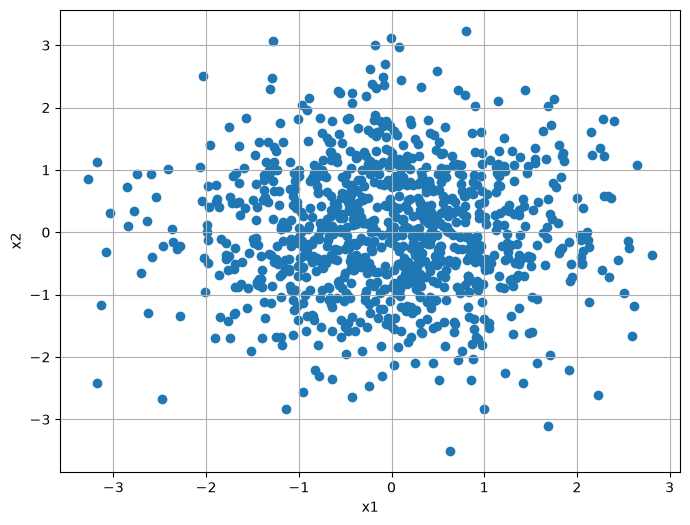

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(raw_data[:,0], raw_data[:,1], marker='o')
plt.grid()
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [6]:
def pre(x):
    return -2.5 * x - 0.5

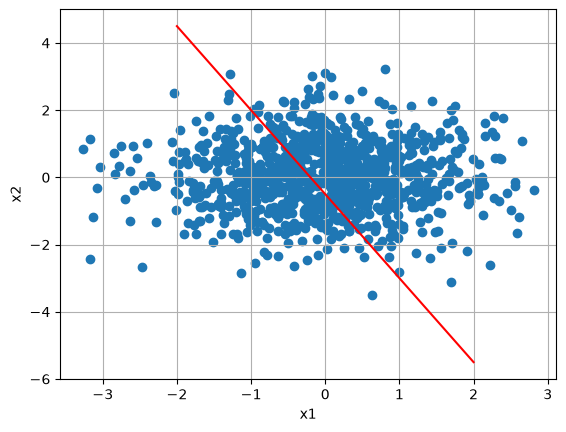

In [7]:
x1 = np.linspace(-2, 2, 500)
plt.plot(x1, pre(x1), color='red')
plt.scatter(raw_data[:,0], raw_data[:,1], marker='o')
plt.grid()
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [8]:
new_raw_data_0 = []
new_raw_data_1 = []
for one_data in raw_data:
    x1 = one_data[0]
    x2 = one_data[1]
    if x2 > pre(x1):
        tag = 1
        new_raw_data_1.append([x1,x2,tag])
    else:
        tag = 0
        new_raw_data_0.append([x1,x2,tag])


In [9]:
def add_noise(x):
    x = x + np.random.random(1)[0] - 0.5
    return x

In [10]:
import array


new_raw_data_0 = [[add_noise(i[0]), add_noise(i[1]), i[2]] for i in new_raw_data_0]
new_raw_data_1 = [[add_noise(i[0]), add_noise(i[1]), i[2]] for i in new_raw_data_1]
new_raw_data_0 = np.array(new_raw_data_0)
new_raw_data_1 = np.array(new_raw_data_1)

In [11]:
new_raw_data_0.shape

(429, 3)

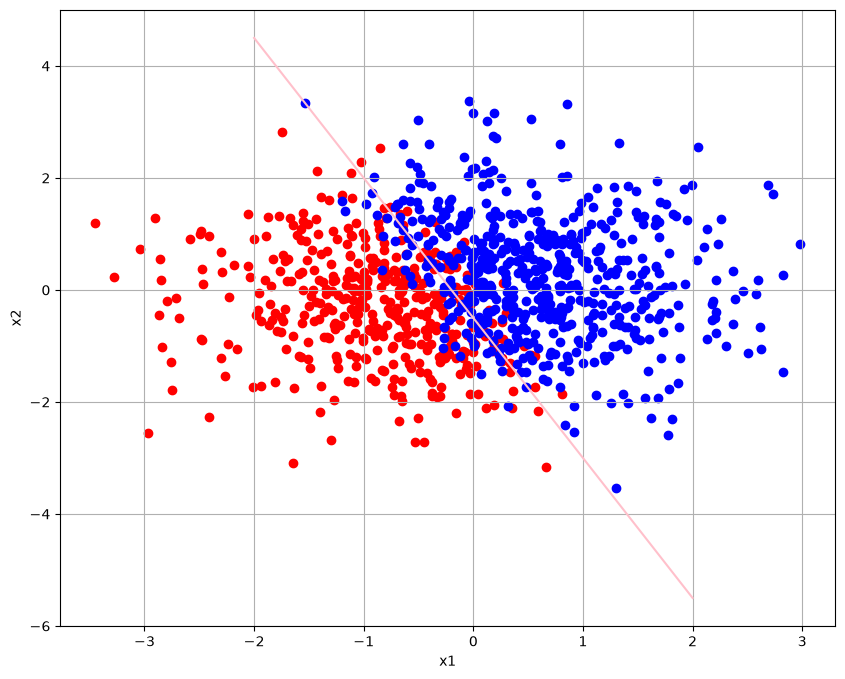

In [12]:
x1 = np.linspace(-2, 2, 500)
plt.figure(figsize=(10, 8))
plt.plot(x1, pre(x1),"pink")
plt.scatter(new_raw_data_0[:,0], new_raw_data_0[:,1], color='red')
plt.scatter(new_raw_data_1[:,0], new_raw_data_1[:,1], color='blue')
plt.grid()
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()


## 数据处理

In [13]:
all_data = np.concatenate((new_raw_data_0, new_raw_data_1), axis=0)
all_data.shape

(1000, 3)

In [14]:
all_data[:5]

array([[ 0.20758009, -0.88020691,  0.        ],
       [-0.53247825,  0.0603832 ,  0.        ],
       [-0.6891987 , -0.34965243,  0.        ],
       [-0.58276023, -1.31665974,  0.        ],
       [-0.93037899, -1.57761957,  0.        ]])

In [15]:
np.random.shuffle(all_data)

In [16]:
all_data[:5]

array([[-2.47427189, -0.90026408,  0.        ],
       [ 0.41145315, -0.38854364,  1.        ],
       [ 1.24089004, -0.05497646,  1.        ],
       [-0.83690022,  0.25792161,  0.        ],
       [-0.97332176,  0.14767065,  0.        ]])

In [17]:
train_data = all_data[:-64]
test_data = all_data[-64:]

## 数据分块

In [18]:
def gen_batch(data, batch_size):
    for i in range(0, len(data), batch_size):
        yield data[i:i+batch_size][:,0:2],data[i:i+batch_size][:,2].reshape(-1,1)

In [19]:
batch_size = 64
for x_,y_ in gen_batch(train_data, batch_size):
    print(x_.shape)
    print(y_.shape)
    break

(64, 2)
(64, 1)


## 超参数

In [20]:
batch_size = 64
learning_rate = 0.01
num_train_epochs = 100
display_step = 100


## 计算图

In [21]:
graph = tf.Graph()
with graph.as_default():
    x = tf.placeholder(shape=[None,2], dtype=tf.float32, name='x')
    y = tf.placeholder(shape=[None,1], dtype=tf.float32, name='y')

    w = tf.Variable(tf.ones(shape=[2,1], dtype=tf.float32), name='w')
    b = tf.Variable(0, dtype=tf.float32, name='b')
    logits = tf.matmul(x, w) + b
    y_pred = tf.sigmoid(logits)
    # 定义损失函数
    loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits, labels=y), name='loss')
    # 定义优化器
    optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate)
    train_step = optimizer.minimize(loss)

## 运行计算图

In [22]:
with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    step = 0
    for epoch in range(num_train_epochs):
        for x_,y_ in gen_batch(train_data, batch_size):
            step += 1
            _, loss_val = sess.run([train_step, loss], feed_dict={x:x_, y:y_})
            if step % display_step == 0:
                w_val = sess.run(w)
                b_val = sess.run(b)
                print(f'Epoch {epoch}, Step {step}, W: {w_val[0,0]:.4f}, Loss: {loss_val:.4f}')
    # 评估模型
    print('training over')
    x_test,y_test = next(gen_batch(test_data, batch_size))
    loss_test = sess.run(loss, feed_dict={x:x_test, y:y_test})
    print(f'Test Loss: {loss_test:.4f}')
    res_weight = sess.run([w,b])
    print(f'Weight: {res_weight}')


Epoch 6, Step 100, W: 1.1589, Loss: 0.3265
Epoch 13, Step 200, W: 1.2957, Loss: 0.3468
Epoch 19, Step 300, W: 1.4165, Loss: 0.3589
Epoch 26, Step 400, W: 1.5239, Loss: 0.2797
Epoch 33, Step 500, W: 1.6206, Loss: 0.3028
Epoch 39, Step 600, W: 1.7092, Loss: 0.3209
Epoch 46, Step 700, W: 1.7905, Loss: 0.2547
Epoch 53, Step 800, W: 1.8656, Loss: 0.2782
Epoch 59, Step 900, W: 1.9360, Loss: 0.2988
Epoch 66, Step 1000, W: 2.0018, Loss: 0.2384
Epoch 73, Step 1100, W: 2.0635, Loss: 0.2621
Epoch 79, Step 1200, W: 2.1222, Loss: 0.2844
Epoch 86, Step 1300, W: 2.1777, Loss: 0.2264
Epoch 93, Step 1400, W: 2.2304, Loss: 0.2504
Epoch 99, Step 1500, W: 2.2809, Loss: 0.2742
training over
Test Loss: 0.2922
Weight: [array([[2.2809298],
       [0.9182602]], dtype=float32), 0.44776133]


## 计算正确率标签

In [23]:
graph = tf.Graph()
with graph.as_default():
    x = tf.placeholder(shape=[None,2], dtype=tf.float32, name='x')
    y = tf.placeholder(shape=[None,1], dtype=tf.float32, name='y')

    w = tf.Variable(tf.ones(shape=[2,1], dtype=tf.float32), name='w')
    b = tf.Variable(0, dtype=tf.float32, name='b')
    logits = tf.matmul(x, w) + b
    y_pred = tf.sigmoid(logits)
    # 定义损失函数
    with tf.name_scope('loss'):
        loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits, labels=y), name='loss')
    # 定义优化器
    with tf.name_scope('SGD'):
        
        optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate)
        train_step = optimizer.minimize(loss)
    # 定义正确率标签
    with tf.name_scope('accuracy'):
        correct_pred = tf.cast(tf.greater_equal(y_pred, 0.5), tf.float32)
        accuracy = tf.reduce_mean(tf.cast(tf.equal(correct_pred,y), tf.float32))


In [ ]:
with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    step = 0
    for epoch in range(num_train_epochs):
        for x_,y_ in gen_batch(train_data, batch_size):
            step += 1
            _, loss_val, accuracy_val = sess.run([train_step, loss, accuracy], feed_dict={x:x_, y:y_})
            if step % display_step == 0:
                w_val = sess.run(w)
                b_val = sess.run(b)
                print(f'Epoch {epoch}, Step {step}, W: {w_val[0,0]:.4f}, Loss: {loss_val:.4f}, Accuracy: {accuracy_val:.4f}')
    # 评估模型
    print('training over')
    x_test,y_test = next(gen_batch(test_data, batch_size))
    loss_test, accuracy_test = sess.run([loss, accuracy], feed_dict={x:x_test, y:y_test})
    print(f'Test Loss: {loss_test:.4f}, Accuracy: {accuracy_test:.4f}')
    res_weight = sess.run([w,b])
    print(f'Weight: {res_weight}')


Epoch 6, Step 100, W: 1.1589, Loss: 0.3265, Accuracy: 0.8750
Epoch 13, Step 200, W: 1.2957, Loss: 0.3468, Accuracy: 0.8750
Epoch 19, Step 300, W: 1.4165, Loss: 0.3589, Accuracy: 0.8750
Epoch 26, Step 400, W: 1.5239, Loss: 0.2797, Accuracy: 0.9062
Epoch 33, Step 500, W: 1.6206, Loss: 0.3028, Accuracy: 0.8750
Epoch 39, Step 600, W: 1.7092, Loss: 0.3209, Accuracy: 0.8750
Epoch 46, Step 700, W: 1.7905, Loss: 0.2547, Accuracy: 0.9062
Epoch 53, Step 800, W: 1.8656, Loss: 0.2782, Accuracy: 0.8906
Epoch 59, Step 900, W: 1.9360, Loss: 0.2988, Accuracy: 0.9000
Epoch 66, Step 1000, W: 2.0018, Loss: 0.2384, Accuracy: 0.9375
Epoch 73, Step 1100, W: 2.0635, Loss: 0.2621, Accuracy: 0.9062
Epoch 79, Step 1200, W: 2.1222, Loss: 0.2844, Accuracy: 0.9000
Epoch 86, Step 1300, W: 2.1777, Loss: 0.2264, Accuracy: 0.9375
Epoch 93, Step 1400, W: 2.2304, Loss: 0.2504, Accuracy: 0.8906
Epoch 99, Step 1500, W: 2.2809, Loss: 0.2742, Accuracy: 0.9000
training over
Test Loss: 0.2922, Accuracy: 0.9062
Weight: [array(

In [33]:
2.2809298/0.9182602

2.483968922969764

In [34]:
0.44776133/0.9182602

0.48761922818826303

## 划线

In [26]:
def formula(x1,w1,w2,b):
    return (-w1*x1-b)/w2



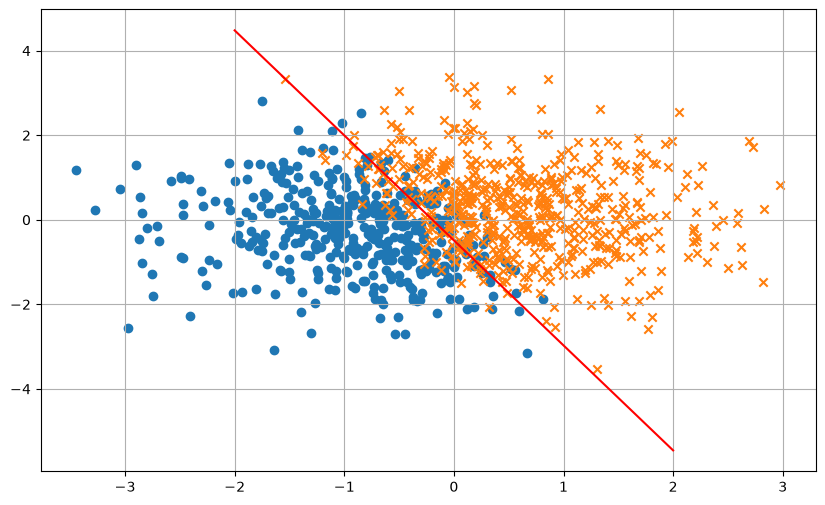

In [30]:
plt.figure(figsize=(10,6))
line_space = np.linspace(-2,2,1024)
plt.scatter(new_raw_data_0[:,0], new_raw_data_0[:,1], marker='o')
plt.scatter(new_raw_data_1[:,0], new_raw_data_1[:,1], marker='x')
w1 = res_weight[0][0][0]
w2 = res_weight[0][1][0]
b = res_weight[1]
plt.plot(line_space, formula(line_space,w1,w2,b), color='red')
plt.grid()
plt.show()
